## 1. Environment Setup

Install Required Library

In [ ]:
!pip install pyspark

#### 1.1 Create SparkContext and SparkSession

Remeber to create a session, which is an entry point to Spark

In [ ]:
# create entry points to spark
from pyspark.sql import SparkSession

ss  = SparkSession.builder \
        .appName("Spark PageRank") \
        .master("local[4]")\
        .getOrCreate()
spark = ss.sparkContext

### 2. PageRank Calculation

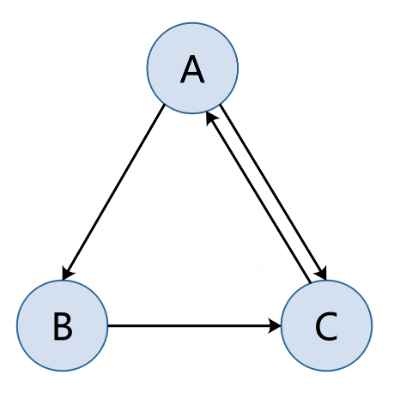

Suppose we have the graph above, and then we can construct the stochastic adjacency matrix (M)

\begin{pmatrix} 0 & 0 & 1 \\ \frac{1}{2} & 0 & 0 \\ \frac{1}{2} & 1 & 0  \end{pmatrix}

Google matrix formula: $$G = βM+(1-β)[1/N]_{NXN}$$

Let $r$ be our rank vector, where r[i] contains the PageRank score for page i in the collection.

The iterative update is: $r^{t+1} = G ⋅ r^t$


Most of the graphs in real scenes are sparse graphs, that is, $M$ is a sparse matrix.

The power method is used to calculate $β⋅M⋅r^t$

PageRank also has a solution algorithm (called "iterative algorithm"), its iterative form is as follows:

$$r^{t+1} = β⋅M⋅r^t + \frac{β}{n}$$

This iterative method avoids the calculation $(1-β)[1/N]_{NXN} ⋅ r^t$, the communication overhead is smaller.

We will adopt this algorithm in today tutorial.

Step 0: Set up the links as tuples: `(1, 2), (1, 3), (2, 3), (3, 1)`, and then convert these links into an RDD.



In [ ]:
links = spark.parallelize([(1, 2), (1, 3), (2, 3), (3, 1)])

**Step 1: Build the adjacent list from RDD.**

In [ ]:
adj_list = ...

[(1, [2, 3]), (2, [3]), (3, [1])]

**Step 2: Compute the number of vertices**

In [ ]:
number_vertices = ...

3

**Step 3: Construct the rank vector, default as 1.0/number_vertices**

In [ ]:
ranks = ...

[(1, 0.3333333333333333), (2, 0.3333333333333333), (3, 0.3333333333333333)]

Then, we can start running our iterative algorithm, $r^{t+1} = β⋅M⋅r^t + \frac{β}{n}$

**Step 4: Set the beta variable to 0.85. Next, combine the adj_list with ranks to create a single RDD for further processing.**

In [ ]:
beta = 0.85
...

[(1, ([2, 3], 0.3333333333333333)),
 (2, ([3], 0.3333333333333333)),
 (3, ([1], 0.3333333333333333))]

**Step 5: Compute the contributions ($M⋅r^t$)**

In [ ]:
from operator import add

...

[(1, 0.3333333333333333), (2, 0.16666666666666666), (3, 0.5)]

Step 6: Compute $r^{t+1}$, where $r^{t+1} = β⋅M⋅r^t + \frac{β}{n}$.

Note that we have computed $M⋅r^t$ in step 5.

In [ ]:
contribution = ...

[(1, 0.3333333333333333), (2, 0.19166666666666668), (3, 0.475)]

**Step 7: Lastly, we should encapsulate the calculation within a loop to compute the difference between $r^t$ and $r^{t+1}$. If this difference is less than the tolerance level (ϵ), the weights are converged will terminate the operation.**

In [ ]:
...

Iteration 1, L1 change: 0.2833333333
Iteration 2, L1 change: 0.2408333333
Iteration 3, L1 change: 0.2047083333
Iteration 4, L1 change: 0.0870010417
Iteration 5, L1 change: 0.0369754427
Iteration 6, L1 change: 0.0314291263
Iteration 7, L1 change: 0.0267147574
Iteration 8, L1 change: 0.0113537719
Iteration 9, L1 change: 0.0048253530
Iteration 10, L1 change: 0.0041015501
Iteration 11, L1 change: 0.0034863176
Iteration 12, L1 change: 0.0014816850
Iteration 13, L1 change: 0.0006297161
Iteration 14, L1 change: 0.0005352587
Iteration 15, L1 change: 0.0004549699
Iteration 16, L1 change: 0.0001933622
Iteration 17, L1 change: 0.0000821789
Converged after 17 iterations.


If you'd like to experiment with page rank on the web, let's consider a folder that contains multiple HTML files. We can build the adjacency list by extracting the links from these files. The code for this is provided in the cell below.

In [ ]:
import os
import re
def extract_links(directory):
  pages = {}

  for filename in os.listdir(directory):
    if not filename.endswith(".html"):
        continue
    with open(os.path.join(directory, filename)) as f:
        contents = f.read()
        links = re.findall(r"<a\s+(?:[^>]*?)href=\"([^\"]*)\"", contents)
        pages[filename] = set(links) - {filename}

  # Only include links to other pages in the corpus
  for filename in pages:
      pages[filename] = set(
          link for link in pages[filename]
          if link in pages
      )

  return pages
